## Phase 3 (Wavelet Transform) — Goal

In Phase 3, we convert each EEG epoch (trial) into a multi-scale feature vector using a Discrete Wavelet Transform (DWT).
This tests whether subject identity is encoded in the multi-scale temporal structure of SSVEP responses (not just a single frequency peak).

### Inputs
- preprocessed_eeg_train.npz for a single subject
- Tensor X with shape `(n_trials, n_channels, n_times)`

### Outputs
- Feature matrix **F** with shape `(n_trials, n_features)` suitable for ML
- **meta** describing exactly what each column of F means:
  - channel, wavelet band, feature name, column index
- Saved `.npz` file containing F + metadata
- Quick sanity-check plots (optional)

## Load One Subject Epoch Tensor

This step loads the preprocessed `.npz` produced in Phase 1.
We expect:

- `X = preprocessed_eeg_data`: shape `(trials, channels, timepoints)`
- `ch_names`: list of channel names (visual cortex electrodes)

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import pywt

# --------------------------
# 0) CONFIG
# --------------------------
SUBJECT = "sub-01"
NPZ_PATH = "my_preprocessed_data/sub-01/preprocessed_eeg_train.npz"

FS = 500.0                  # Hz (from your preprocessing)
WAVELET = "db4"             # common choice for EEG
LEVEL = 5                   # adjust based on n_times (501 supports ~5-7 levels)
FEATURES_PER_BAND = ["energy", "log_energy", "mean", "std", "entropy"]  # simple, robust

OUT_DIR = "./wavelet_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# --------------------------
# 1) LOAD ONE SUBJECT
# --------------------------
data = np.load(NPZ_PATH, allow_pickle=True)
X = data["preprocessed_eeg_data"]   # (trials, channels, time)
ch_names = list(data["ch_names"])

print("Loaded:", NPZ_PATH)
print("X shape:", X.shape)
print("Channels:", ch_names)

n_trials, n_channels, n_times = X.shape


Loaded: my_preprocessed_data/sub-01/preprocessed_eeg_train.npz
X shape: (67200, 8, 501)
Channels: [np.str_('O1'), np.str_('Oz'), np.str_('O2'), np.str_('PO3'), np.str_('PO4'), np.str_('PO7'), np.str_('PO8'), np.str_('POz')]


## Feature Definitions (What We Compute Per Band)

For each wavelet coefficient band (e.g., A5, D5, D4, ...), we compute:

| Feature | Description |
|---|---|
| **Energy** | Overall power in that band |
| **Log-energy** | Stabilizes scale differences |
| **Mean** | Amplitude center |
| **Std** | Amplitude spread |
| **Entropy** | Complexity / dispersion of energy within the band |

These are simple and robust features often used in EEG biometrics.

---

### Wavelet Bands and EEG Frequency Alignment

The DWT decomposes the signal by repeatedly applying a **pair of filters** to the input:

- A **low-pass filter** captures slow, coarse structure → produces approximation coefficients (`cA`)
- A **high-pass filter** captures fast, fine-grained detail → produces detail coefficients (`cD`)

At each level, the filtered output is **downsampled by 2**, halving the effective sample rate. This means each successive level operates on a signal at half the bandwidth of the previous one, naturally partitioning the frequency axis into dyadic (power-of-2) bands.

Given our sampling rate of **500 Hz** and a preprocessing bandpass of **1–40 Hz**, the wavelet bands roughly align with traditional EEG rhythms:

| Wavelet Band | Approx. Frequency Range | EEG Rhythm |
|---|---|---|
| **A5** | ~1–4 Hz | Delta |
| **D5** | ~4–8 Hz | Theta |
| **D4** | ~8–16 Hz | Alpha / low Beta |
| **D3** | ~16–32 Hz | Beta |
| **D2** | ~32–40 Hz | Low Gamma (edge of bandpass) |
| **D1** | >40 Hz | Mostly noise (filtered out in preprocessing) |

> **Note:** D1 coefficients represent frequencies above 40 Hz, which were already attenuated by the bandpass filter in Phase 1. They are included in the feature matrix for completeness but carry little meaningful signal.

By computing statistical features within each band **per channel**, we obtain a structured representation that preserves both **frequency-domain** (which band) and **spatial** (which electrode) information — making it well-suited for subject identity classification.

In [15]:

# --------------------------
# 2) UTILS: feature funcs
# --------------------------
def shannon_entropy(x, eps=1e-12):
    """Entropy of |x|^2 normalized as a probability distribution."""
    p = (x**2)
    p = p / (np.sum(p) + eps)
    return -np.sum(p * np.log(p + eps))

def coeff_features(c, eps=1e-12):
    """Return feature vector for one coefficient array."""
    e = np.sum(c**2)
    return {
        "energy": e,
        "log_energy": np.log(e + eps),
        "mean": np.mean(c),
        "std": np.std(c),
        "entropy": shannon_entropy(c, eps=eps),
    }

def dwt_decompose(signal_1d, wavelet=WAVELET, level=LEVEL):
    """
    Returns coeffs in PyWavelets format:
      [cA_L, cD_L, cD_{L-1}, ..., cD_1]
    """
    # Ensure level is valid for this signal length
    max_level = pywt.dwt_max_level(len(signal_1d), pywt.Wavelet(wavelet).dec_len)
    use_level = min(level, max_level)
    return pywt.wavedec(signal_1d, wavelet, level=use_level)

## Build Feature Layout (Interpretability Layer)

A critical deliverable is **interpretability**: we must be able to answer:

> *"What does column k in F represent?"*

So we build a `layout` list mapping each column to:
- **channel name** (e.g., `Oz`)
- **wavelet band** (e.g., `D4`)
- **feature type** (e.g., `energy`)
- **column index**

This layout guarantees column ordering is consistent and explainable.



In [ ]:

# --------------------------
# 3) FEATURE EXTRACTION (DWT)
# --------------------------

def extract_subject_wavelet_features(X, wavelet=WAVELET, level=LEVEL, feature_keys=FEATURES_PER_BAND):
    """
    Input:
      X: (trials, channels, time)
    Output:
      F: (trials, n_features)  where features are concatenated over channels and bands
      meta: dict describing feature layout
    """
    n_trials, n_channels, _ = X.shape
    
    # Determine decomposition structure using first trial/channel
    coeffs0 = dwt_decompose(X[0, 0, :], wavelet=wavelet, level=level)
    n_bands = len(coeffs0)  # includes cA and all cD's
    band_names = ["A{}".format(n_bands-1)] + ["D{}".format(i) for i in range(n_bands-1, 0, -1)]
    # Example: ["A5","D5","D4","D3","D2","D1"]

    # feature count per (channel, band)
    f_per_cb = len(feature_keys)
    total_features = n_channels * n_bands * f_per_cb

    F = np.zeros((n_trials, total_features), dtype=np.float32)

    # Build meta layout: (channel, band, feature) -> column index
    layout = []
    col = 0

    for ch in range(n_channels):   # dennis: third loop is over bands, innermost loop is over features, try PyWavelets or joblib
        for b, bname in enumerate(band_names):
            for fk in feature_keys:
                layout.append((ch_names[ch], bname, fk, col))
                col += 1

    # Extract
    for t in range(n_trials):
        col = 0
        for ch in range(n_channels):
            coeffs = dwt_decompose(X[t, ch, :], wavelet=wavelet, level=level)

            # coeffs order: [cA_L, cD_L, cD_{L-1}, ..., cD_1]
            for c in coeffs:
                feats = coeff_features(c)
                for fk in feature_keys:
                    F[t, col] = feats[fk]
                    col += 1

        if (t + 1) % 5000 == 0:
            print(f"Processed {t+1}/{n_trials} trials...")

    meta = {
        "wavelet": wavelet,
        "level": level,
        "feature_keys": feature_keys,
        "n_trials": n_trials,
        "n_channels": n_channels,
        "n_bands": n_bands,
        "band_names": band_names,
        "layout": layout,  # list of tuples (ch_name, band, feature, col)
    }
    return F, meta

print("\nExtracting wavelet features...")
F, meta = extract_subject_wavelet_features(X)

print("Feature matrix shape:", F.shape)
print("Example layout row:", meta["layout"][0])



Extracting wavelet features...
Processed 5000/67200 trials...
Processed 10000/67200 trials...
Processed 15000/67200 trials...
Processed 20000/67200 trials...
Processed 25000/67200 trials...
Processed 30000/67200 trials...
Processed 35000/67200 trials...
Processed 40000/67200 trials...
Processed 45000/67200 trials...
Processed 50000/67200 trials...
Processed 55000/67200 trials...
Processed 60000/67200 trials...
Processed 65000/67200 trials...
Feature matrix shape: (67200, 240)
Example layout row: (np.str_('O1'), 'A5', 'energy', 0)


In [22]:

print("F shape:", F.shape)
print("Num layout entries:", len(meta["layout"]))

# -------------------------
# 1) Print first K layout entries
# -------------------------
K = 30
print("\n=== First layout entries (column meanings) ===")
for (ch, band, feat, col) in meta["layout"][:K]:
    print(f"col {col:3d}: {ch:>4s} | {band:>3s} | {feat}")


F shape: (67200, 240)
Num layout entries: 240

=== First layout entries (column meanings) ===
col   0:   O1 |  A5 | energy
col   1:   O1 |  A5 | log_energy
col   2:   O1 |  A5 | mean
col   3:   O1 |  A5 | std
col   4:   O1 |  A5 | entropy
col   5:   O1 |  D5 | energy
col   6:   O1 |  D5 | log_energy
col   7:   O1 |  D5 | mean
col   8:   O1 |  D5 | std
col   9:   O1 |  D5 | entropy
col  10:   O1 |  D4 | energy
col  11:   O1 |  D4 | log_energy
col  12:   O1 |  D4 | mean
col  13:   O1 |  D4 | std
col  14:   O1 |  D4 | entropy
col  15:   O1 |  D3 | energy
col  16:   O1 |  D3 | log_energy
col  17:   O1 |  D3 | mean
col  18:   O1 |  D3 | std
col  19:   O1 |  D3 | entropy
col  20:   O1 |  D2 | energy
col  21:   O1 |  D2 | log_energy
col  22:   O1 |  D2 | mean
col  23:   O1 |  D2 | std
col  24:   O1 |  D2 | entropy
col  25:   O1 |  D1 | energy
col  26:   O1 |  D1 | log_energy
col  27:   O1 |  D1 | mean
col  28:   O1 |  D1 | std
col  29:   O1 |  D1 | entropy


In [23]:

# -------------------------
# 2) Print a small view of F with meanings
#    - first R rows (trials)
#    - first C columns (features)
# -------------------------
R = 3
C = 12

print(f"\n=== First {R} trials × first {C} columns of F (with meanings) ===")

# Build nice header labels for the first C columns
col_labels = []
for j in range(C):
    ch, band, feat, col = meta["layout"][j]
    col_labels.append(f"{ch}-{band}-{feat}")

# Print header
print("trial_idx | " + " | ".join([f"{lab:>18s}" for lab in col_labels]))
print("-" * (10 + (C * 22)))

# Print values
for i in range(R):
    vals = [f"{F[i, j]:18.6g}" for j in range(C)]
    print(f"{i:8d} | " + " | ".join(vals))



=== First 3 trials × first 12 columns of F (with meanings) ===
trial_idx |       O1-A5-energy |   O1-A5-log_energy |         O1-A5-mean |          O1-A5-std |      O1-A5-entropy |       O1-D5-energy |   O1-D5-log_energy |         O1-D5-mean |          O1-D5-std |      O1-D5-entropy |       O1-D4-energy |   O1-D4-log_energy
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       0 |        7.25702e-07 |           -14.1361 |       -0.000148078 |        0.000105163 |            2.61681 |        3.61264e-08 |           -17.1362 |        3.68751e-06 |        4.03548e-05 |            2.16231 |        1.02549e-08 |           -18.3954
       1 |        3.40331e-07 |           -14.8933 |       -9.61796e-05 |        7.88612e-05 |            2.61524 |        2.92158e-08 |  

In [24]:

# -------------------------
# 3) Optional: decode a specific column index
# -------------------------
col_idx = 37
ch, band, feat, col = meta["layout"][col_idx]
print(f"\nColumn {col_idx} means: channel={ch}, band={band}, feature={feat}")
print(f"Example values (first {R} trials) for col {col_idx}: {F[:R, col_idx]}")


Column 37 means: channel=Oz, band=D5, feature=mean
Example values (first 3 trials) for col 37: [ 4.7031390e-06  2.7893675e-06 -1.3324052e-07]


## Save Deliverable 

We save:
- `X_features` (the matrix F)
- `metadata` (layout, band names, channel names, etc.)

This `.npz` is the direct input to classification and confusion matrix generation.

Saved: ./wavelet_outputs/sub-01_wavelet_features_db4_L5.npz
NaNs: 0  Infs: 0


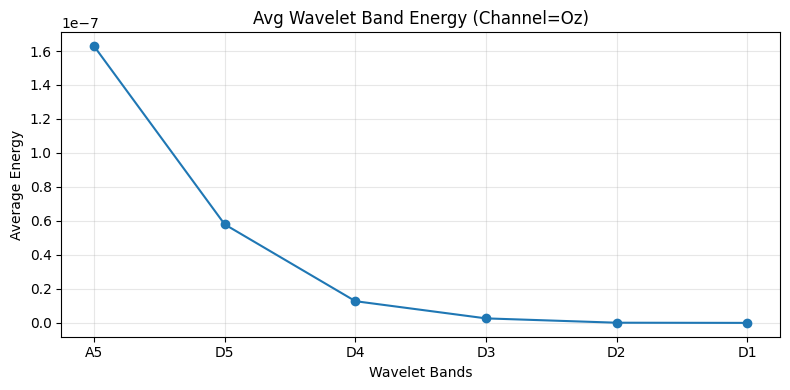

In [17]:

# --------------------------
# 4) SAVE FEATURES
# --------------------------
out_path = os.path.join(OUT_DIR, f"{SUBJECT}_wavelet_features_{WAVELET}_L{meta['n_bands']-1}.npz")
np.savez(
    out_path,
    X_features=F,
    subject_id=SUBJECT,
    ch_names=np.array(ch_names),
    band_names=np.array(meta["band_names"]),
    feature_keys=np.array(meta["feature_keys"]),
    layout=np.array(meta["layout"], dtype=object),
    wavelet=meta["wavelet"],
    level=meta["level"],
)
print("Saved:", out_path)

# --------------------------
# 5) QUICK SANITY CHECKS
# --------------------------
# A) Look for NaNs / infs
print("NaNs:", np.isnan(F).sum(), " Infs:", np.isinf(F).sum())

# B) Visualize per-band energy (averaged across trials) for one channel (e.g., Oz)
def plot_avg_band_energy_for_channel(F, meta, channel_name="Oz"):
    band_names = meta["band_names"]
    feature_keys = meta["feature_keys"]
    layout = meta["layout"]
    
    # Find column indices for (channel_name, band, "energy")
    energy_cols = []
    for (ch, band, feat, col) in layout:
        if ch == channel_name and feat == "energy":
            energy_cols.append((band, col))
    if not energy_cols:
        print(f"Channel {channel_name} not found or no energy feature.")
        return

    # Keep order aligned with band_names
    band_to_col = {band: col for band, col in energy_cols}
    cols_ordered = [band_to_col[b] for b in band_names if b in band_to_col]

    avg_energy = np.mean(F[:, cols_ordered], axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(band_names, avg_energy, marker="o")
    plt.title(f"Avg Wavelet Band Energy (Channel={channel_name})")
    plt.xlabel("Wavelet Bands")
    plt.ylabel("Average Energy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_avg_band_energy_for_channel(F, meta, channel_name="Oz")


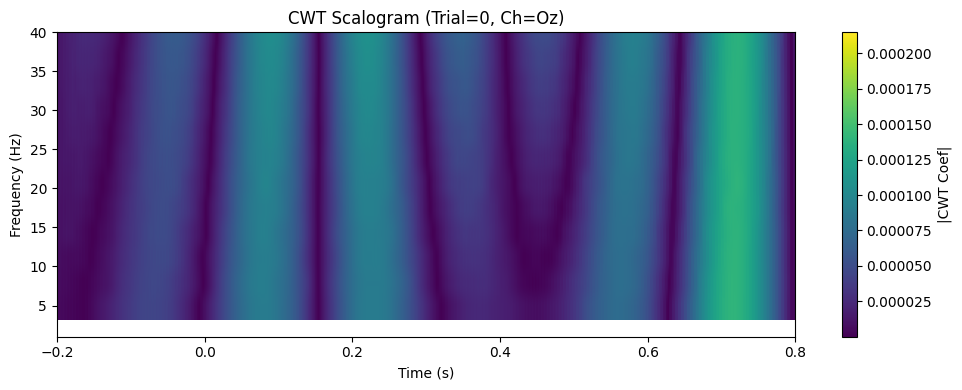

In [18]:

# --------------------------
# 6) OPTIONAL: TIME-FREQUENCY LOOK (CWT Scalogram) for ONE trial+channel
# --------------------------
def plot_cwt_scalogram(X, ch_names, trial_idx=0, channel_name="Oz", fs=500.0, wavelet="morl"):
    if channel_name not in ch_names:
        channel_name = ch_names[0]
    ch_idx = ch_names.index(channel_name)

    sig = X[trial_idx, ch_idx, :]
    t = np.arange(len(sig)) / fs - 0.2  # your epoch window starts at -0.2
    
    # Choose scales; larger scales ~ lower freq
    scales = np.arange(1, 128)
    coef, freqs = pywt.cwt(sig, scales, wavelet, sampling_period=1/fs)

    plt.figure(figsize=(10, 4))
    plt.imshow(
        np.abs(coef),
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], freqs[0], freqs[-1]],
    )
    plt.colorbar(label="|CWT Coef|")
    plt.title(f"CWT Scalogram (Trial={trial_idx}, Ch={channel_name})")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.ylim(1, 40)  # match your preprocessing band
    plt.tight_layout()
    plt.show()

plot_cwt_scalogram(X, ch_names, trial_idx=0, channel_name="Oz", fs=FS)